<div style="text-align: center;">

<!-- color:#e06666 -->
<h3 style="font-weight: normal; margin-bottom: 10px;">
EN3160 Assignment 01
</h3>

<h3 style="font-weight: normal; line-height: 1.5; margin-top: 0;">
Intensity Transformations and Neighborhood Filtering
</h3>

<!-- <br><br> -->

<h4 style="font-family: 'Times New Roman', serif; font-weight: normal; margin-top: 0; line-height: 1.4;">
230138K  - K.T.G.T.N.Dhananjaya 
</h4>

<br>
<!-- <h4 style="font-family: 'Times New Roman', serif; font-weight: normal;">
September 4, 2026
</h4> -->

</div>

<a href="https://github.com/TharushaNimesh22/intensity-transformations-and-neighborhood-filtering">GitHub Link: https://github.com/TharushaNimesh22/intensity-transformations-and-neighborhood-filtering </a>

##### 1. Intensity Transformation

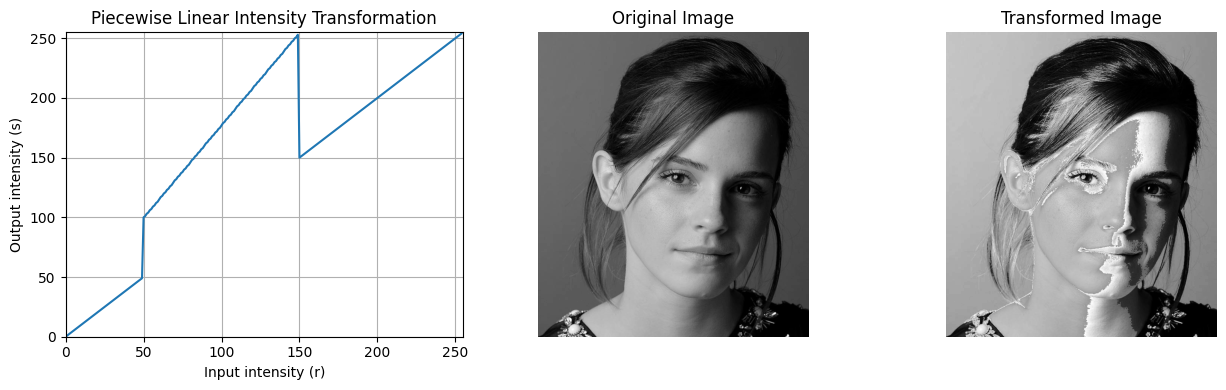

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    transformed = np.zeros_like(im, dtype=np.uint8)
    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]
        # Calculate the slope (m) and intercept (b) of the line segment
        if x1 - x0 != 0:
            m = (y1 - y0) / (x1 - x0)
            b = y0 - m * x0
        else:
            m, b = 0, y0
        # Apply the linear transformation for the current segment
        mask = (im >= x0) & (im < x1)
        transformed[mask] = np.clip(m * im[mask] + b, 0, 255)
    return transformed.astype(np.uint8)

# Read image using OpenCV
im = cv.imread("images/emma.jpeg", cv.IMREAD_GRAYSCALE)
breakpoints = np.array([[0, 0], [50, 50],[50, 100], [150, 255],[150, 150], 
                        [255, 255],])
transformed = intensity_transform(im, breakpoints)
# Plot the transformation function
r = np.arange(255)
s = intensity_transform(r, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(r, s)    # Transformation function
axes[0].set(xlabel="Input intensity (r)", ylabel="Output intensity (s)", 
            title="Piecewise Linear Intensity Transformation", xlim=(0, 255), ylim=(0, 255))
axes[0].grid()
axes[1].imshow(im, cmap="gray")    # Original image
axes[1].set_title("Original Image")
axes[1].axis("off")
axes[2].imshow(transformed, cmap="gray")  # Transformed image
axes[2].set_title("Transformed Image")
axes[2].axis("off")
plt.tight_layout()
plt.show()

##### 2. Intensity transformers for white matter and gray matter

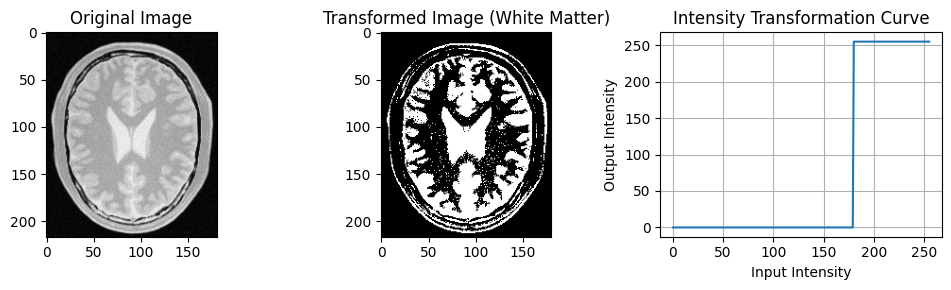

In [ ]:
f = cv.imread("images/brain.png", cv. IMREAD_GRAYSCALE)
#part a). White matter enhancement
t1= np.linspace(0, 0, 180, endpoint=False).astype("uint8")
t2= np.linspace(255, 255, 76).astype("uint8")
tr1= np.concatenate((t1, t2)).reshape(256, 1)

img_wm = cv.LUT(f, tr1)
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title("Original Image")
ax[1].imshow(img_wm, cmap='gray', vmin=0, vmax=255)
ax[1].set_title("Transformed Image (White Matter)")
ax[2].plot(tr1)
ax[2].set_title("Intensity Transformation Curve")
ax[2].set_xlabel("Input Intensity")
ax[2].set_ylabel("Output Intensity")
ax[2].grid(True)

plt.tight_layout()
plt.show()

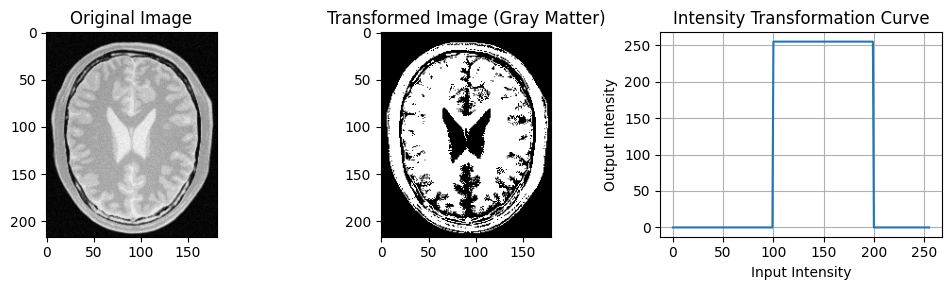

In [5]:
# Gray matter enhancement
gm_low = np.linspace(0, 0, 100, endpoint=False).astype("uint8")
gm_boost = np.linspace(255, 255, 100, endpoint=False).astype("uint8")
gm_high = np.linspace(0, 0, 56).astype("uint8")
tr_gm = np.concatenate((gm_low, gm_boost, gm_high)).reshape(256, 1)

img_gm = cv.LUT(f, tr_gm)
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255); ax[0].set_title("Original Image")

ax[1].imshow(img_gm, cmap='gray', vmin=0, vmax=255);
ax[1].set_title("Transformed Image (Gray Matter)");ax[2].plot(tr_gm)
ax[2].set_title("Intensity Transformation Curve"); ax[2].set_xlabel("Input Intensity")
ax[2].set_ylabel("Output Intensity");ax[2].grid(True)
plt.tight_layout()
plt.show()



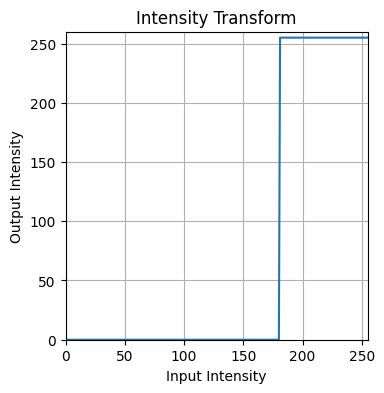

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Define thresholds for white matter intensity enhancement
lower_thresh = 180  
upper_thresh = 255  

# Define intensity mapping points 
c = np.array([(0, lower_thresh), (lower_thresh, upper_thresh)])

# Generate the transformation
t1 = np.linspace(0, c[0,0], c[0,1] + 1 - 0).astype('uint8')
t2 = np.linspace(c[1,1], 255, 255 - c[1,0]).astype('uint8')

# Concatenate the two transformation parts into a single transformation array
transform = np.concatenate((t1, t2), axis=0).astype('uint8')

# Ensure the transformation has exactly 256 values, covering all possible intensity values (0 to 255)
assert len(transform) == 256

# Plot the transformation function
fig, ax = plt.subplots()
fig.set_size_inches(4,4)  

# Plot the transformation function
ax.plot(transform)
ax.grid(True) 
ax.set_title('Intensity Transform')  
ax.set_xlabel('Input Intensity') 
ax.set_ylabel('Output Intensity')  
ax.set_xlim(0, 255)  
ax.set_ylim(0, 260)  
ax.set_aspect('equal')  

# Save the plot to a PNG file
plt.savefig('white_matter_transform.png')

# Display the plot on the screen
plt.show()

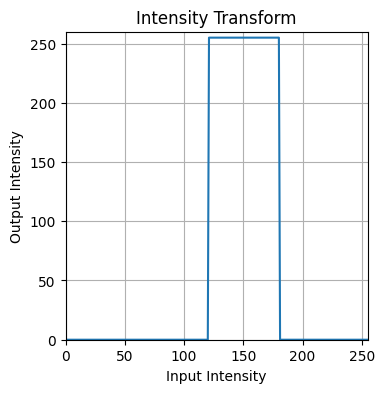

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Define thresholds for gray matter intensity enhancement
lower_thresh = 120  
upper_thresh = 180  

# Define intensity mapping points 
c = np.array([(0,lower_thresh),(lower_thresh,255),(upper_thresh,255)])

# Generate the transformation
t1 = np.linspace(0, c[0,0], c[0,1]+1-0).astype('uint8')
t2 = np.linspace(c[1,1],c[2,1],c[2,0] - c[1,0] ).astype('uint8')
t3 = np.linspace(0, 0, 255 - c[2,0]).astype('uint8')

# Concatenate the two transformation parts into a single transformation array
transform = np.concatenate((t1, t2), axis=0).astype('uint8')
transform = np.concatenate((transform, t3), axis=0).astype('uint8')

# Ensure the transformation has exactly 256 values, covering all possible intensity values (0 to 255)
assert len(transform) == 256

# Plot the transformation function
fig, ax = plt.subplots()
fig.set_size_inches(4, 4)  

# Plot the transformation function
ax.plot(transform)
ax.grid(True) 
ax.set_title('Intensity Transform')  
ax.set_xlabel('Input Intensity') 
ax.set_ylabel('Output Intensity')  
ax.set_xlim(0, 255)  
ax.set_ylim(0, 260)  
ax.set_aspect('equal')  

# Save the plot to a PNG file
plt.savefig('gray_matter_transform.png')

# Display the plot on the screen
plt.show()